# Decision Tree - Heart Disease

Explores a tuned Decision Tree classifier on the cleaned splits.

**Method.** Hyperparameters are tuned with stratified 5-fold `GridSearchCV` on the
**training** set; the tuned model is evaluated on the **validation** set. The
**test** set is deliberately left untouched here - it is reserved for the final
cross-model comparison notebook, so the hold-out is spent only once.

Decision Trees split on one feature at a time, so they are invariant to
monotonic rescaling - no scaler is added to the pipeline and the model-ready
columns are used as-is.

In [1]:
import sys
from pathlib import Path

# Make the scripts/ helpers importable from notebooks/.
sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score, f1_score, accuracy_score,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay,
)
from sklearn.tree import plot_tree

from dataset import load_splits, get_xy
from train_models import build_pipeline, MODELS, CV

MODEL_NAME = "decision_tree"

## Load data

In [2]:
train, val, test = load_splits()
X_train, y_train = get_xy(train)
X_val, y_val = get_xy(val)

print(f"train {X_train.shape}  val {X_val.shape}  (test held back)")
print(f"train disease rate {y_train.mean():.3f}  val {y_val.mean():.3f}")

train (552, 15)  val (184, 15)  (test held back)
train disease rate 0.553  val 0.554


## Tune hyperparameters (train, 5-fold CV)

The estimator and grid come straight from the `MODELS` registry in
`train_models.py`, so the notebook and the batch script stay in sync.

In [3]:
cfg = MODELS[MODEL_NAME]
pipe = build_pipeline(cfg["estimator"], cfg["needs_scaling"], list(X_train.columns))
search = GridSearchCV(pipe, cfg["grid"], cv=CV, scoring="roc_auc", n_jobs=-1)
search.fit(X_train, y_train)

best = search.best_estimator_
print("best params:", search.best_params_)
print(f"cv roc-auc: {search.best_score_:.3f}")

best params: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 5}
cv roc-auc: 0.805


## Validation metrics

In [4]:
proba = best.predict_proba(X_val)[:, 1]
pred = best.predict(X_val)

metrics = {
    "roc_auc": roc_auc_score(y_val, proba),
    "recall": recall_score(y_val, pred),
    "precision": precision_score(y_val, pred),
    "f1": f1_score(y_val, pred),
    "accuracy": accuracy_score(y_val, pred),
}
pd.Series(metrics, name=MODEL_NAME).round(3)

roc_auc      0.807
recall       0.794
precision    0.764
f1           0.779
accuracy     0.750
Name: decision_tree, dtype: float64

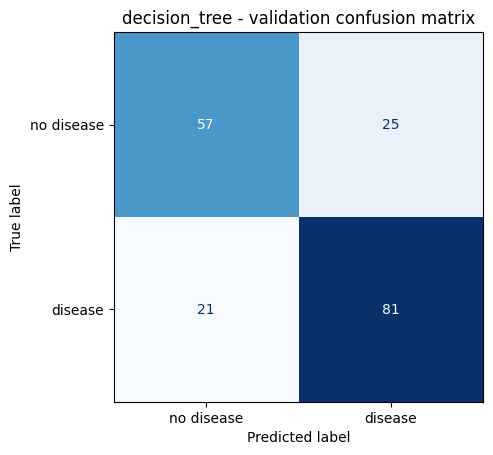

In [5]:
ConfusionMatrixDisplay(
    confusion_matrix(y_val, pred), display_labels=["no disease", "disease"]
).plot(cmap="Blues", colorbar=False)
plt.title(f"{MODEL_NAME} - validation confusion matrix")
plt.show()

## Hyperparameter comparison

A single tree overfits quickly: `max_depth` caps how many questions the tree
may ask, `min_samples_leaf` stops it from carving out tiny leaves, and
`criterion` picks the impurity measure. The table shows the ten best
cross-validated configurations.

In [6]:
cv_results = pd.DataFrame(search.cv_results_)
param_cols = ["param_model__max_depth", "param_model__min_samples_leaf", "param_model__criterion"]

tree_grid = cv_results[param_cols + ["mean_test_score", "std_test_score"]].copy()
tree_grid = tree_grid.rename(columns={
    "param_model__max_depth": "max_depth",
    "param_model__min_samples_leaf": "min_samples_leaf",
    "param_model__criterion": "criterion",
    "mean_test_score": "cv_roc_auc",
    "std_test_score": "cv_std",
})
tree_grid.sort_values("cv_roc_auc", ascending=False).head(10).round(3)

,max_depth,min_samples_leaf,criterion,cv_roc_auc,cv_std
20,5,5,entropy,0.805,0.055
5,5,5,gini,0.805,0.049
2,3,5,gini,0.800,0.035
17,3,5,entropy,0.797,0.042
18,5,1,entropy,0.793,0.069
1,3,3,gini,0.792,0.038
26,10,5,entropy,0.790,0.046
16,3,3,entropy,0.789,0.042
15,3,1,entropy,0.789,0.042
4,5,3,gini,0.788,0.057


## How performance varies with depth and leaf size

Holding the best `criterion` fixed, plot the cross-validated ROC-AUC across
`max_depth` for each `min_samples_leaf`. This shows the bias/variance
trade-off: shallow trees underfit, deep unconstrained trees memorize the
training folds, and a larger leaf minimum blunts the damage of extra depth
(`None` = unbounded depth).

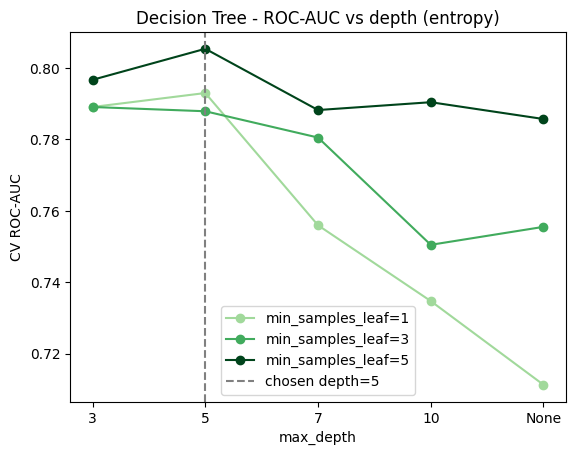

In [7]:
best_criterion = search.best_params_["model__criterion"]
depth_order = cfg["grid"]["model__max_depth"]
depth_labels = [str(d) for d in depth_order]

# One line per leaf size, light-to-dark as the constraint tightens.
leaf_colors = dict(zip(cfg["grid"]["model__min_samples_leaf"], ["#a1d99b", "#41ab5d", "#00441b"]))

for leaf, color in leaf_colors.items():
    rows = tree_grid[
        (tree_grid["criterion"] == best_criterion) & (tree_grid["min_samples_leaf"] == leaf)
    ]
    score_by_depth = dict(zip(rows["max_depth"], rows["cv_roc_auc"]))
    plt.plot(depth_labels, [score_by_depth[d] for d in depth_order],
             marker="o", color=color, label=f"min_samples_leaf={leaf}")

plt.axvline(str(search.best_params_["model__max_depth"]), color="gray", ls="--",
            label=f"chosen depth={search.best_params_['model__max_depth']}")
plt.xlabel("max_depth")
plt.ylabel("CV ROC-AUC")
plt.title(f"Decision Tree - ROC-AUC vs depth ({best_criterion})")
plt.legend()
plt.show()

## Feature importance

Tree impurity importances show which features the fitted tree used most often
for high-value splits. They are useful diagnostics, but they can favor
continuous features or variables with more split points. Features with zero
importance were never used in a split and are dropped from the chart.

Caveat: ~22% of `chol` is iteratively imputed with low-variance synthetic
values (see PROJECT.md), so read its importance with that in mind.

In [8]:
tree = best.named_steps["model"]
importance = pd.Series(tree.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).round(3)

cp_4         0.336
age          0.149
chol         0.139
oldpeak      0.120
trestbps     0.081
exang        0.074
sex          0.052
thalach      0.049
fbs          0.000
cp_2         0.000
cp_1         0.000
cp_3         0.000
restecg_0    0.000
restecg_1    0.000
restecg_2    0.000
dtype: float64

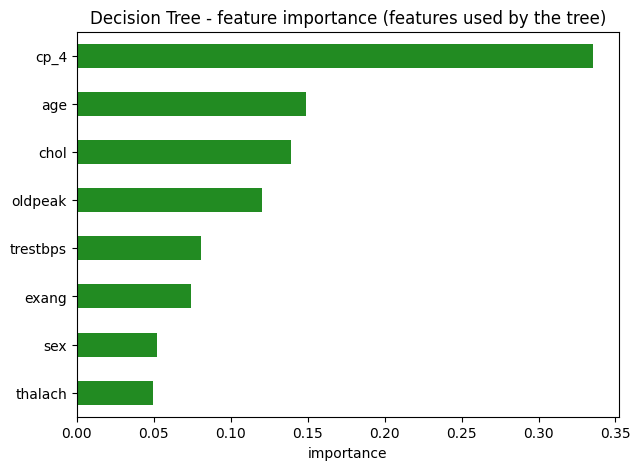

In [9]:
used = importance[importance > 0].sort_values()

used.plot(kind="barh", color="forestgreen", figsize=(7, 5))
plt.xlabel("importance")
plt.title("Decision Tree - feature importance (features used by the tree)")
plt.show()

## Tree structure

Show the first few levels of the fitted tree so the main decision logic is
readable. The plot is intentionally depth-limited even if the tuned tree is
deeper.

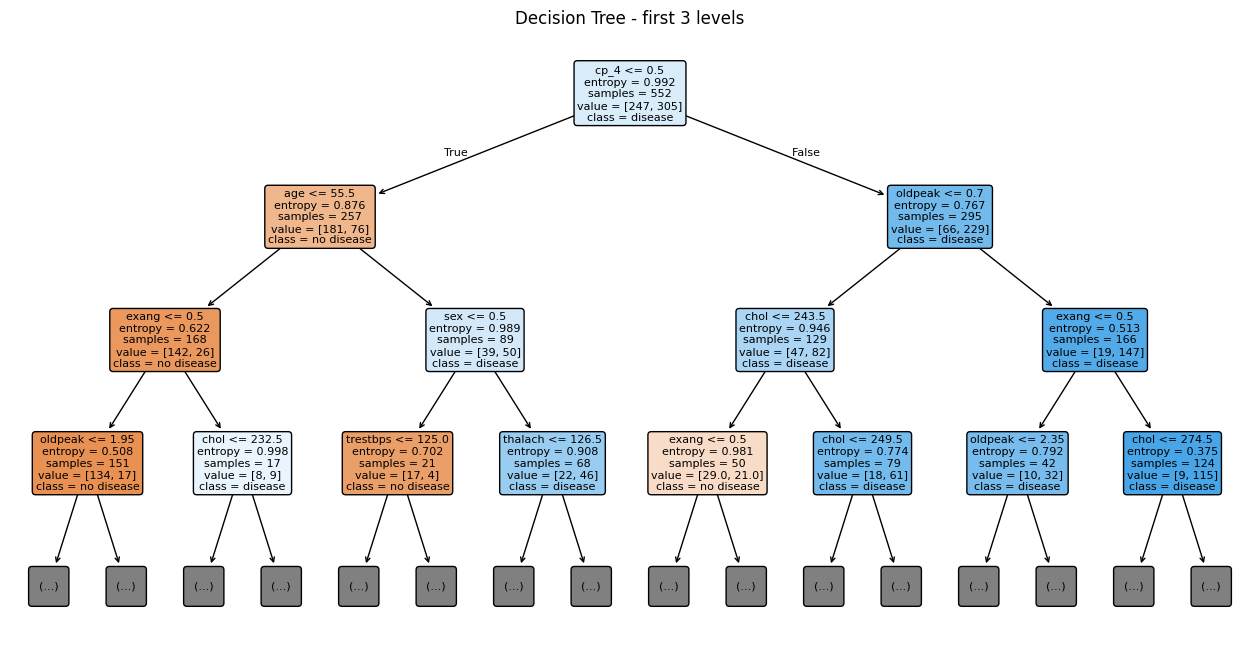

In [10]:
plt.figure(figsize=(16, 8))
plot_tree(
    tree,
    feature_names=list(X_train.columns),
    class_names=["no disease", "disease"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Decision Tree - first 3 levels")
plt.show()

## ROC curve (validation)

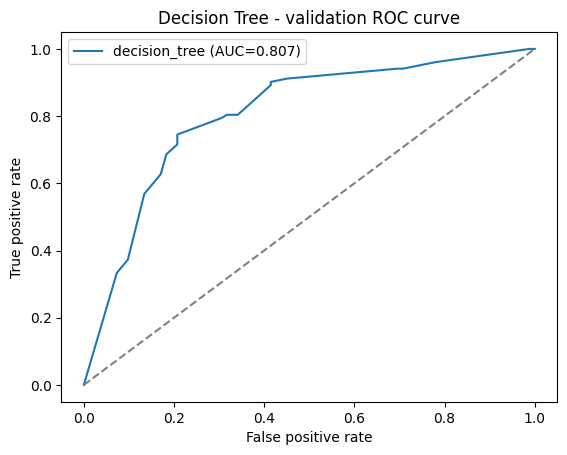

In [11]:
fpr, tpr, _ = roc_curve(y_val, proba)
plt.plot(fpr, tpr, label=f"{MODEL_NAME} (AUC={metrics['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], ls="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Decision Tree - validation ROC curve")
plt.legend()
plt.show()

## Notes

- Test set intentionally not touched - see the comparison notebook for the
  single final test evaluation of the selected model.
- A single tree's ROC curve is step-like: `predict_proba` comes from leaf
  class fractions, so there are only as many distinct scores as leaves.
- This notebook is Decision Tree specific. To explore another model, start
  from the shared template and swap in a model-appropriate diagnostic.